<a href="https://colab.research.google.com/github/Amruth-U-tech/DL-Journey/blob/main/04-RNNs/StatefulRNN-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**RNN arctecture on aplle stack market data set**

In [2]:
#the apple stock market data set is in yahoo finance website so we install that dependiencie here
!pip install yfinance


In [3]:
import yfinance as yf
import numpy as np
import pandas as pd #for data handling or to read
import matplotlib.pyplot as plt #to print any 2D instance
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Bidirectional, Input  #we got two RNNs here
from tensorflow.keras.optimizers import Adam


In [4]:
df = yf.download("AAPL",period="5y",auto_adjust=True)[["Close"]]  #we are dowloding "AAPL" which mean aplle stock market data of period 5years

#with the target variable as close which means there is a feature in that data known as close which shos the closing price of the stock and that Y
df.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2021-03-17,121.515694
2021-03-18,117.395699
2021-03-19,116.869751
2021-03-22,120.181305
2021-03-23,119.353424
2021-03-24,116.967125
2021-03-25,117.454140
2021-03-26,118.057991


In [5]:
df.shape


(1256, 1)

**preprocessing the data**

In [6]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
scaled_data

array([[2.79862931e-02],
       [3.62785615e-03],
       [5.18323159e-04],
       ...,
       [7.88326944e-01],
       [8.04290088e-01],
       [8.12655881e-01]])

In [7]:
from pandas.core.window.rolling import Window
#now because this is Sequential data we make our x and Y in such a way itself
#such that some input X1 will give some input Y1 then that Y1 is included with X1 by removing previous data of X1 hence X2=X1-X1[0]+Y1 we get Y2

def create_sequence(data,window=30):
  X,Y = [],[]
  for i in range(window,len(data)):
    X.append(data[i-window:i])
    Y.append(data[i])
  return np.array(X),np.array(Y)

Window_size = 30
x,y = create_sequence(scaled_data,window=Window_size)


In [8]:
x.shape

(1226, 30, 1)

In [9]:
y.shape

(1226, 1)

In [10]:
#tain and test split
split = int(len(x)*0.8)
x_train,x_test = x[:split],x[split:]
y_train,y_test = y[:split],y[split:]
#note that u cannot split it as we did for other tabular data or anything cause these are squential

In [11]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(980, 30, 1) (246, 30, 1) (980, 1) (246, 1)


In [12]:
#remember from the RNN structure and match the beloow data as a sequense data
print(x[0])
print(y[0])   #this y_train[0] should be equal to x[30]th first value which is on 30th day

#what it means is from the sequense of 0 to 29th day data we predict the target value and shall get y[0] which is the price of 30th day stock
#check below

[[0.02798629]
 [0.00362786]
 [0.00051832]
 [0.02009705]
 [0.01520242]
 [0.00109402]
 [0.00397337]
 [0.00754349]
 [0.00858005]
 [0.        ]
 [0.01295659]
 [0.01785132]
 [0.03455092]
 [0.03633612]
 [0.04606797]
 [0.06023374]
 [0.07543625]
 [0.06530132]
 [0.08367078]
 [0.06985057]
 [0.08407422]
 [0.08211586]
 [0.08603213]
 [0.07606973]
 [0.0783156 ]
 [0.06933212]
 [0.08303757]
 [0.08534091]
 [0.08344056]
 [0.07877614]]
[0.07820058]


In [13]:
print(x[30])  #checking on 30th day stock price

[[0.07820058]
 [0.06656824]
 [0.07278739]
 [0.04577987]
 [0.04721969]
 [0.05666353]
 [0.06064381]
 [0.04126229]
 [0.03584021]
 [0.01772768]
 [0.03041791]
 [0.04472325]
 [0.03791653]
 [0.02972566]
 [0.02880277]
 [0.04391574]
 [0.03307124]
 [0.04270431]
 [0.0415507 ]
 [0.04126229]
 [0.03220609]
 [0.02834142]
 [0.02643768]
 [0.03093691]
 [0.02216931]
 [0.03572478]
 [0.03578239]
 [0.04062772]
 [0.04287738]
 [0.03699387]]


Text(0, 0.5, 'closing price')

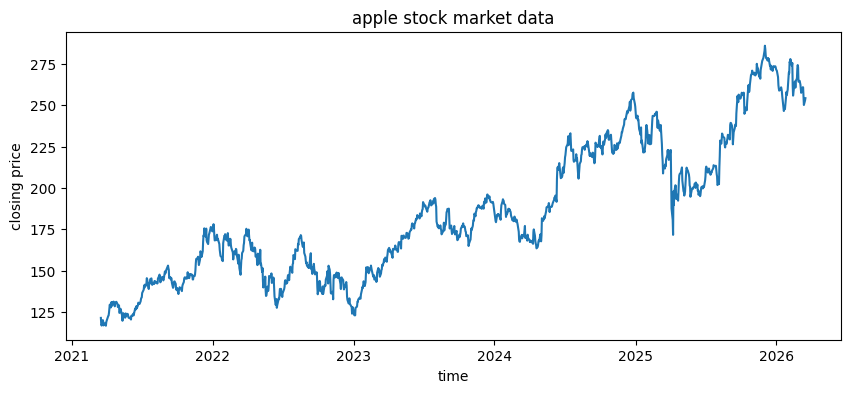

In [14]:
plt.figure(figsize=(10,4))
plt.plot(df["Close"])
plt.title("apple stock market data")
plt.xlabel("time")
plt.ylabel("closing price")


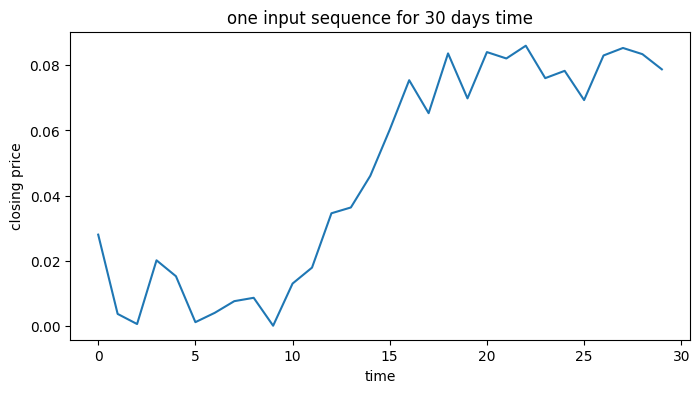

In [15]:
plt.figure(figsize=(8,4))
plt.plot(x[0])
plt.title("one input sequence for 30 days time")
plt.xlabel("time")
plt.ylabel("closing price")
plt.show()

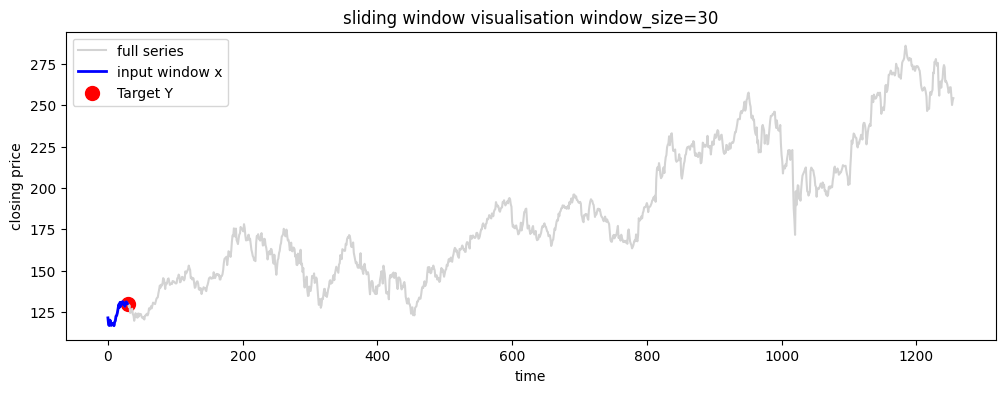

In [16]:
i = 30
Window_size=30
plt.figure(figsize=(12,4))

#full series plot
plt.plot(df["Close"].values,color="lightgray",label="full series")

#ploting sliding window on the sma e plot (same as mtlab if u dont create another figure instance it will be ploted ont he same graph)
plt.plot(range(i-Window_size,i),df["Close"].values[i-Window_size:i],color="blue",linewidth=2,label="input window x")

plt.scatter(i,df["Close"].values[i],color="red",s=100,label="Target Y")
plt.title("sliding window visualisation window_size=30")
plt.xlabel("time")
plt.ylabel("closing price")
plt.legend()
plt.show()

In [17]:
#now building an simple rnn

model_rnn = Sequential([SimpleRNN(50,return_sequences=False,input_shape=(Window_size,1)),Dense(1)])
model_rnn.compile(optimizer="adam",loss="mse")
model_rnn.summary()



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history_rnn = model_rnn.fit(x_train,y_train,epochs=10,batch_size=32,validation_data=(x_test,y_test))


Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0190 - val_loss: 0.0079
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - val_loss: 0.0036
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.5478e-04 - val_loss: 0.0033
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.7827e-04 - val_loss: 0.0029
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.2117e-04 - val_loss: 0.0026
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7932e-04 - val_loss: 0.0018
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.4001e-04 - val_loss: 0.0022
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.1413e-04 - val_loss: 0.0019
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.7703e-04 - val_loss: 0.0019
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.5522e-04 - val_loss: 0.0019


In [19]:
#model prediction
prediction = model_rnn.predict(x_test)
prediction=scaler.inverse_transform(prediction)
y_test1 = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
  print(f"prdeiction: {prediction[i][0]:.2f}, actual:{y_test1[i][0]:.2f}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
prdeiction: 217.32, actual:222.78
prdeiction: 219.32, actual:220.57
prdeiction: 219.32, actual:222.88
prdeiction: 222.35, actual:216.95
prdeiction: 223.47, actual:221.17
prdeiction: 219.22, actual:222.22
prdeiction: 220.44, actual:222.92
prdeiction: 219.63, actual:202.31
prdeiction: 216.95, actual:187.56
prdeiction: 206.33, actual:180.67
prdeiction: 193.74, actual:171.67
prdeiction: 179.94, actual:197.99
prdeiction: 178.73, actual:189.59
prdeiction: 187.18, actual:197.29
prdeiction: 188.99, actual:201.64
prdeiction: 201.40, actual:201.26
prdeiction: 205.44, actual:193.43
prdeiction: 199.33, actual:196.13
prdeiction: 198.35, actual:192.32
prdeiction: 192.58, actual:198.87
prdeiction: 190.73, actual:203.71
prdeiction: 203.94, actual:207.47
prdeiction: 203.36, actual:208.37
prdeiction: 207.65, actual:209.23
prdeiction: 208.35, actual:210.29
prdeiction: 208.42, actual:211.58
prdeiction: 210.06, actual:212.39
prdeiction: 215.46, actual:204.46
prdeiction

In [20]:
#u can plot the prdictited values and actual values to see graphically how closely the model is folowing

#NOw lets build stacled rnn
model_deep_rnn = Sequential([SimpleRNN(50, return_sequences=True, input_shape=(Window_size,1)),SimpleRNN(50),Dense(1)])
model_deep_rnn.compile(optimizer="adam",loss="mse") #u need return_sequense true so that the next layer of rnn gets some input or u will get error
model_deep_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 30, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_bid = Sequential([Bidirectional(SimpleRNN(50),input_shape=(Window_size,1)),Dense(1)])
model_bid.compile(optimizer="adam",loss="mse")
model_bid.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 100)            │         5,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,301 (20.71 KB)

 Trainable params: 5,301 (20.71 KB)

 Non-trainable params: 0 (0.00 B)

**State full RNN structure**

In [22]:
batch = 32
model_statefull = Sequential([Input(batch_shape=(batch,Window_size,1)),SimpleRNN(50,stateful=True),Dense(1)])

model_statefull.compile(optimizer="adam",loss="mse")  #in stateful rnn u have to explicitly describe how many batchs u want because the training length must be divisible by batch size

model_statefull.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (32, 50)               │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 1)                │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
train_len = len(x_train)-(len(x_train)%batch)

x_train_s = x_train[:train_len]
y_train_s = y_train[:train_len]

print(f"trimmed training shape:{x_train_s.shape,y_train_s.shape}")

trimmed training shape:((960, 30, 1), (960, 1))


In [24]:
from IPython.core import history
stateful_loss = []

for i in range(10):
  print(f"epoch:{i+1}")

  history = model_statefull.fit(x_train_s,y_train_s,epochs=1,batch_size=batch,shuffle=False)

  stateful_loss.append(history.history["loss"][0])

  for layer in model_statefull.layers:
    if hasattr(layer,"reset_states"):
      layer.reset_states()

epoch:1
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0037
epoch:2
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0041
epoch:3
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0012
epoch:4
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.5774e-04
epoch:5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.7278e-04
epoch:6
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.0806e-04
epoch:7
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.0597e-04
epoch:8
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.5296e-04
epoch:9
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1134e-04
epoch:10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.8084e-04
